# Assignment 4 - Trees

In this assignment, you will delve into the world of decision trees and their ensemble counterparts. 

You'll work with the breast cancer dataset to understand how these algorithms can be utilized for classification tasks, and you'll also explore the importance of feature selection and hyperparameter tuning.

## Tasks:

### 1. Data Loading and Exploration: (1 point)

In [3]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# part 1: Data Loading and Exploration
from sklearn.datasets import load_breast_cancer

# Load the dataset
"""
Question: Load Breast Cancer Dataset (1 point)
Using Scikit-learn's datasets module, load the breast cancer dataset.

Hints:

- Import the necessary function from Scikit-learn's datasets module.
- Assign the feature data to a variable named `X` and target labels to a variable named `y`.
- Remember to utilize the `load_breast_cancer()` function.
"""

data = load_breast_cancer()
print(data.keys()) 
X = data.data
y = data.target


print("shape of data: ",data.data.shape)
print("shape of target: ",data.target.shape)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
shape of data:  (569, 30)
shape of target:  (569,)


### 2. Data Preprocessing (1 point)

In [8]:
# part 2: Data Preprocessing
from sklearn.model_selection import train_test_split

"""
Question: Dataset Preprocessing (1 point)
Using the loaded breast cancer dataset, divide it into training and testing sets.

Hints:

Utilize the train_test_split function.
Remember to set test_size and random_state.
"""

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=25)
print("Shape of training set",X_train.shape)
print("Shape of testing set",y_test.shape)

Shape of training set (398, 30)
Shape of testing set (171,)


### 3. Decision Trees (4 points)

Decision Tree Accuracy: 90.06%


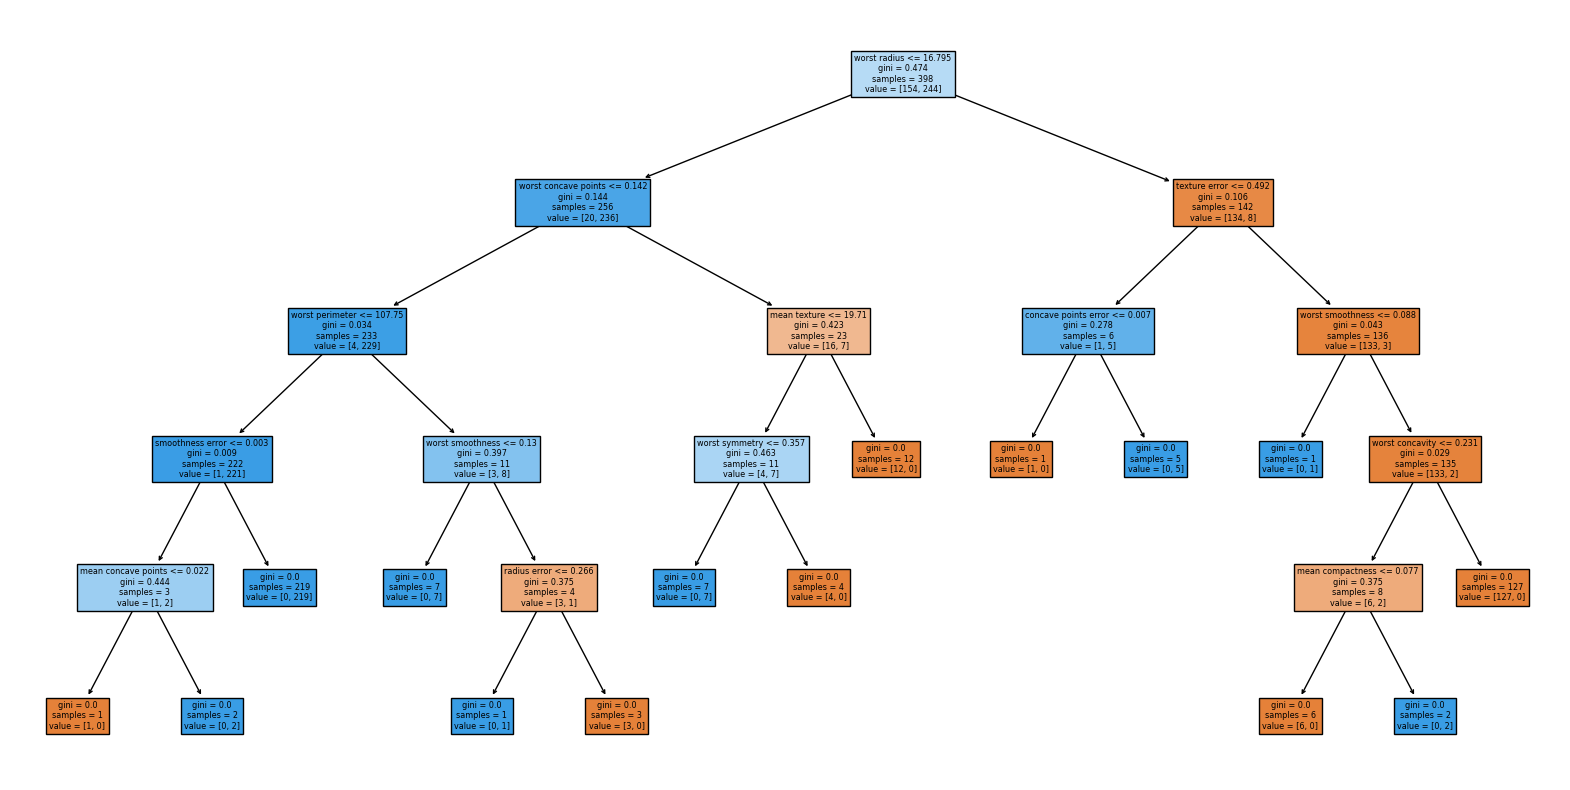

In [11]:
# part 3: Decision Trees
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

"""
Question: Decision Trees Implementation (4 points)
Using the training data, implement a decision tree classifier and evaluate its accuracy on the testing data.

Hints:

- Initialize a DecisionTreeClassifier.
- Train the classifier using the fit method on the training data.
- Predict the labels of the testing data.
- Calculate and print the accuracy of the classifier.
- Visualize the decision tree using the plot_tree function. Make sure to use the feature_names from the data for clarity.
"""

# Decision Trees
dt = DecisionTreeClassifier(random_state=25)
#fit the tree dt
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy*100:.2f}%")
plt.figure(figsize=(20,10))
plot_tree(dt, filled= True , feature_names= data.feature_names)
plt.show()

### 4. Random Forest (8 points)

In [14]:
# part 4: Random Forest
from sklearn.ensemble import RandomForestClassifier

"""
Question: Random Forest Implementation (4 points)
Using the training data, implement a random forest classifier and evaluate its accuracy on the testing data.

Hints:

- Initialize a RandomForestClassifier.
- Train the classifier using the fit method on the training data.
- Predict the labels of the testing data.
- Calculate and print the accuracy of the classifier.
"""


rf = RandomForestClassifier(random_state=25)
# fit the random forest rf
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy*100:.2f}%")

# Feature importances

"""
Question: Feature Importance Analysis (4 points)
Using the trained Random Forest model, analyze and list down the importance of features in descending order.

Hints:

- Use the feature_importances_ attribute of the trained Random Forest model to get the importance of each feature.
- Sort the features based on their importance in descending order.
- Print the ranked features along with their importance values.
"""

# look for random forest on sklearn
importances = rf.feature_importances_
# look for https://numpy.org/doc/stable/reference/generated/numpy.argsort.html
indices = np.argsort(importances)[::-1]
print("Feature ranking:")
for f in range(X.shape[1]):
    print(f"{f+1}. {data.feature_names[indices[f]]} ({importances[indices[f]]:.4f})")

Random Forest Accuracy: 95.91%
Feature ranking:
1. worst radius (0.1208)
2. worst area (0.1160)
3. worst perimeter (0.1157)
4. mean concave points (0.0996)
5. worst concave points (0.0862)
6. mean concavity (0.0628)
7. mean radius (0.0589)
8. mean perimeter (0.0578)
9. area error (0.0538)
10. mean area (0.0436)
11. worst concavity (0.0338)
12. worst compactness (0.0289)
13. worst texture (0.0138)
14. mean texture (0.0121)
15. perimeter error (0.0117)
16. worst symmetry (0.0106)
17. concavity error (0.0093)
18. worst smoothness (0.0079)
19. mean compactness (0.0076)
20. radius error (0.0063)
21. smoothness error (0.0059)
22. worst fractal dimension (0.0059)
23. fractal dimension error (0.0052)
24. mean symmetry (0.0052)
25. mean smoothness (0.0050)
26. texture error (0.0043)
27. concave points error (0.0035)
28. mean fractal dimension (0.0029)
29. compactness error (0.0027)
30. symmetry error (0.0022)


In [16]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


### 5. XGBoost (4 points)

In [19]:
# Part 5: XGBoost
import xgboost as xgb

"""
Question: Implementing XGBoost (4 points)
Using the XGBoost library, train a classifier on the training data and evaluate its accuracy on the test set.

Hints:

- Initialize the XGBoost classifier using xgb.XGBClassifier().
- Fit the classifier on the training data.
- Predict the labels for the test set using the trained model.
- Evaluate and print the accuracy of the predictions against the true test labels.
"""

clf = xgb.XGBClassifier(random_state=25)
# fit the clf
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"XGBoost Accuracy: {accuracy*100:.2f}%")

XGBoost Accuracy: 95.91%


### 6. Hyperparameter Tuning (2 points)

In [26]:
from sklearn.model_selection import GridSearchCV

"""
Question: Hyperparameter Tuning for Random Forest (4 points)
Using the provided param_grid for hyperparameters, apply Grid Search to find the optimal hyperparameters for a Random Forest classifier.

Hints:

- Utilize GridSearchCV with the given parameter grid param_grid and a 5-fold cross validation.
- Fit the GridSearch on the training data.
- After finding the best parameters, retrieve the best estimator using best_estimator_ attribute.
- Predict the labels for the test set using the optimized Random Forest model.
- Evaluate and print the accuracy of the predictions against the true test labels.
"""

# For this assignment, we'll only tune for Random Forest here
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# define GridSearchCV with cv=5
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)
# find best estimator
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
print(f"Optimized Random Forest Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Optimized Random Forest Accuracy: 94.74%
